# Power Flux Inversion Analysis

Analyzes how **solar production**, **storage capacity**, and **household demand** affect
power flux inversion at LV transformers across 192 simulations (3 solar levels × 4 storage levels × 16 random seeds).

**Power flux inversion** occurs when a transformer absorbs power from the LV side (P > 0),
meaning local generation exceeds local consumption and energy flows back to the MV grid.
In an ideal grid, transformers should only deliver power (P < 0).

In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import re
from sqlalchemy import create_engine, text

load_dotenv()

db_url = (
    f"postgresql://{os.getenv('POSTGRES_DB_USER', 'root')}"
    f":{os.getenv('POSTGRES_DB_PASSWORD', 'skamasfrevrest')}"
    f"@{os.getenv('POSTGRES_DB_HOST', '103.0.2.7')}"
    f":{os.getenv('POSTGRES_DB_PORT', '5433')}"
    f"/{os.getenv('POSTGRES_DB_NAME', 'duilio')}"
)
engine = create_engine(db_url)
conn = engine.connect()
print('Connected to database')

Connected to database


## 1. Load All 192 Simulations

Fetch the last 192 converged simulations (IDs 241–432) and extract their parameters.

In [2]:
# Fetch the last 192 converged simulations
sims_df = pd.read_sql_query(
    text("""
        SELECT simulation_output_id, parameters
        FROM building_power.simulation_outputs
        WHERE parameters ->> 'name' LIKE 'Solar-%%-Storage-%%-seed%%.json'
          AND converged = true
        ORDER BY simulation_output_id DESC
        LIMIT 192
    """),
    conn
)

# Parse parameters from JSON
sims_df['name'] = sims_df['parameters'].apply(lambda p: p.get('name', ''))
sims_df['random_seed'] = sims_df['parameters'].apply(lambda p: p.get('random_seed'))

def parse_name(name):
    m = re.match(r'Solar-(\d+)-Storage-(\d+)-seed(\d+)', name)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))
    return None, None, None

sims_df[['solar_kw', 'storage_kwh', 'seed']] = sims_df['name'].apply(
    lambda n: pd.Series(parse_name(n))
)

# Extract load power range
sims_df['load_kw'] = sims_df['parameters'].apply(
    lambda p: p.get('load_power_range_per_branch_kW', [5, 5])[0]
)

sims_df = sims_df.sort_values('simulation_output_id').reset_index(drop=True)

print(f"Loaded {len(sims_df)} simulations")
print(f"ID range: {sims_df['simulation_output_id'].min()} – {sims_df['simulation_output_id'].max()}")
print(f"Solar levels: {sorted(sims_df['solar_kw'].unique())} kW")
print(f"Storage levels: {sorted(sims_df['storage_kwh'].unique())} kWh")
print(f"Seeds per combo: {sims_df.groupby(['solar_kw', 'storage_kwh']).size().iloc[0]}")

Loaded 192 simulations
ID range: 241 – 432
Solar levels: [5, 10, 20] kW
Storage levels: [0, 5, 10, 20] kWh
Seeds per combo: 16


## 2. Query Transformer LV Power for All Simulations

For each simulation, query per-phase, per-transformer LV power **individually** (P_a_lv, P_b_lv, P_c_lv for each transformer index).
Each (transformer, phase) pair is analyzed separately — this prevents inversions on one transformer/phase
from being masked by consumption on another when summing.
Positive power = inversion (LV → MV absorbing).

In [3]:
from query_helpers_simplified import get_timeseries_by_element

PHASES = ['a', 'b', 'c']

# For each simulation, fetch per-transformer, per-phase LV power individually
results = []

for i, row in sims_df.iterrows():
    sim_id = row['simulation_output_id']
    
    for phase in PHASES:
        var_name = f'P_{phase}_lv[MW]'
        df_by_elem = get_timeseries_by_element(
            conn, sim_id, element_type='transformer', output_name=var_name
        )
        
        if df_by_elem.empty:
            continue
        
        # Process each transformer individually
        for trafo_idx, trafo_data in df_by_elem.groupby('element_index'):
            trafo_data = trafo_data.sort_values('bucket')
            p_kw = trafo_data['value'].values * 1e3  # MW -> kW
            
            n_steps = len(p_kw)
            n_inversion = np.sum(p_kw > 0)
            inversion_fraction = n_inversion / n_steps if n_steps > 0 else 0
            
            peak_inversion_kw = np.max(p_kw) if n_inversion > 0 else 0
            
            inverted = p_kw[p_kw > 0]
            mean_inversion_kw = np.mean(inverted) if len(inverted) > 0 else 0
            
            step_hours = 0.25
            total_inverted_kwh = np.sum(inverted) * step_hours if len(inverted) > 0 else 0
            
            delivered = p_kw[p_kw < 0]
            total_delivered_kwh = np.abs(np.sum(delivered)) * step_hours if len(delivered) > 0 else 0
            
            total_energy = total_inverted_kwh + total_delivered_kwh
            inversion_energy_ratio = total_inverted_kwh / total_energy if total_energy > 0 else 0
            
            results.append({
                'simulation_output_id': sim_id,
                'name': row['name'],
                'solar_kw': row['solar_kw'],
                'storage_kwh': row['storage_kwh'],
                'seed': row['seed'],
                'load_kw': row['load_kw'],
                'phase': phase,
                'trafo_idx': trafo_idx,
                'n_steps': n_steps,
                'n_inversion_steps': n_inversion,
                'inversion_time_fraction': inversion_fraction,
                'peak_inversion_kw': peak_inversion_kw,
                'mean_inversion_kw': mean_inversion_kw,
                'total_inverted_kwh': total_inverted_kwh,
                'total_delivered_kwh': total_delivered_kwh,
                'inversion_energy_ratio': inversion_energy_ratio,
                'p_timeseries_kw': p_kw,
            })
    
    if (i + 1) % 24 == 0:
        print(f"  Processed {i + 1}/{len(sims_df)} simulations...")

inv_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'p_timeseries_kw'} for r in results])
n_trafos = inv_df['trafo_idx'].nunique()
print(f"\nProcessed {len(results)} records ({len(sims_df)} sims × {n_trafos} trafos × {len(PHASES)} phases)")
print(f"Transformers: {sorted(inv_df['trafo_idx'].unique())}")
print(f"Records per simulation: {len(results) // len(sims_df)}")

  Processed 24/192 simulations...
  Processed 48/192 simulations...
  Processed 72/192 simulations...
  Processed 96/192 simulations...
  Processed 120/192 simulations...
  Processed 144/192 simulations...
  Processed 168/192 simulations...
  Processed 192/192 simulations...

Processed 2880 records (192 sims × 5 trafos × 3 phases)
Transformers: ['0', '1', '2', '3', '4']
Records per simulation: 15


## 2b. Query Household Consumption for All Simulations

For each simulation, fetch the **total household consumption** (sum of all household producers across all phases: `P_a_load`, `P_b_load`, `P_c_load`).
This is the aggregate demand that competes with solar generation — when solar exceeds consumption, inversion occurs.
We also fetch per-phase consumption to match the per-phase transformer analysis.

In [16]:
from query_helpers_simplified import get_timeseries_data

# For each simulation, fetch total household consumption (all phases summed)
household_results = []

for i, row in sims_df.iterrows():
    sim_id = row['simulation_output_id']
    
    # Total consumption: P_%_load[MW] sums P_a_load, P_b_load, P_c_load across all households
    hh_df = get_timeseries_data(
        conn, sim_id,
        element_type='householdproducer',
        output_name='P_%_load[MW]'
    )
    
    if hh_df.empty:
        continue
    
    hh_df = hh_df.sort_values('bucket')
    consumption_kw = hh_df['total_quantity'].values * 1000  # MW -> kW (negative = consuming)
    
    step_hours = 0.25
    n_steps = len(consumption_kw)
    
    # Consumption is negative in the convention, so total consumed = abs(sum of negatives)
    total_consumed_kwh = np.abs(np.sum(consumption_kw[consumption_kw < 0])) * step_hours
    mean_consumption_kw = np.abs(np.mean(consumption_kw[consumption_kw < 0])) if np.any(consumption_kw < 0) else 0
    peak_consumption_kw = np.abs(np.min(consumption_kw))  # most negative = peak consumption
    
    household_results.append({
        'simulation_output_id': sim_id,
        'solar_kw': row['solar_kw'],
        'storage_kwh': row['storage_kwh'],
        'seed': row['seed'],
        'load_kw': row['load_kw'],
        'n_steps': n_steps,
        'total_consumed_kwh': total_consumed_kwh,
        'mean_consumption_kw': mean_consumption_kw,
        'peak_consumption_kw': peak_consumption_kw,
        'consumption_timeseries_kw': consumption_kw,
    })
    
    if (i + 1) % 24 == 0:
        print(f"  Processed {i + 1}/{len(sims_df)} simulations...")

hh_consumption_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'consumption_timeseries_kw'} for r in household_results])
print(f"\nLoaded household consumption for {len(household_results)} simulations")
print(f"Mean total consumption: {hh_consumption_df['total_consumed_kwh'].mean():.1f} kWh over simulation period")
print(f"Mean consumption power: {hh_consumption_df['mean_consumption_kw'].mean():.2f} kW")
print(f"Mean peak consumption:  {hh_consumption_df['peak_consumption_kw'].mean():.2f} kW")

  Processed 24/192 simulations...
  Processed 48/192 simulations...
  Processed 72/192 simulations...
  Processed 96/192 simulations...
  Processed 120/192 simulations...
  Processed 144/192 simulations...
  Processed 168/192 simulations...
  Processed 192/192 simulations...

Loaded household consumption for 192 simulations
Mean total consumption: 3716.5 kWh over simulation period
Mean consumption power: 15.15 kW
Mean peak consumption:  43.46 kW


## 3. Summary Statistics Table

Aggregated inversion metrics per Solar-Storage combination (mean ± std across all transformer-phase pairs and 16 seeds).
Each data point is one (transformer, phase) timeseries from one simulation seed.
Now includes **household consumption** data to contextualize the inversion magnitudes.

In [17]:
# Merge household consumption into inversion data
inv_df = inv_df.merge(
    hh_consumption_df[['simulation_output_id', 'total_consumed_kwh', 'mean_consumption_kw', 'peak_consumption_kw']],
    on='simulation_output_id',
    how='left'
)

# Summary table: mean and std across seeds/trafos/phases for each Solar×Storage combo
summary = inv_df.groupby(['solar_kw', 'storage_kwh']).agg(
    n_records=('seed', 'count'),
    inv_time_mean=('inversion_time_fraction', 'mean'),
    inv_time_std=('inversion_time_fraction', 'std'),
    peak_inv_mean=('peak_inversion_kw', 'mean'),
    peak_inv_std=('peak_inversion_kw', 'std'),
    mean_inv_mean=('mean_inversion_kw', 'mean'),
    mean_inv_std=('mean_inversion_kw', 'std'),
    energy_ratio_mean=('inversion_energy_ratio', 'mean'),
    energy_ratio_std=('inversion_energy_ratio', 'std'),
    total_inverted_mean=('total_inverted_kwh', 'mean'),
    total_inverted_std=('total_inverted_kwh', 'std'),
    total_consumed_mean=('total_consumed_kwh', 'mean'),
    mean_consumption_mean=('mean_consumption_kw', 'mean'),
    peak_consumption_mean=('peak_consumption_kw', 'mean'),
).reset_index()

print(f"{'Solar':>7} {'Storage':>8} {'N':>5}  {'Time Inverted':>16}  "
      f"{'Peak Inv (kW)':>16}  {'Mean Cons (kW)':>16}  {'Energy Ratio':>16}")
print('-' * 110)

for _, r in summary.iterrows():
    print(
        f"{int(r['solar_kw']):>5}kW {int(r['storage_kwh']):>6}kWh {int(r['n_records']):>5}  "
        f"{r['inv_time_mean']:>6.1%} ± {r['inv_time_std']:>5.1%}  "
        f"{r['peak_inv_mean']:>6.2f} ± {r['peak_inv_std']:>5.2f}  "
        f"{r['mean_consumption_mean']:>6.2f} kW (total)   "
        f"{r['energy_ratio_mean']:>6.1%} ± {r['energy_ratio_std']:>5.1%}"
    )

  Solar  Storage     N     Time Inverted     Peak Inv (kW)    Mean Cons (kW)      Energy Ratio
--------------------------------------------------------------------------------------------------------------
    5kW      0kWh   240   13.2% ± 10.3%    1.58 ±  1.10    3.50 kW (total)    10.7% ± 16.7%
    5kW      5kWh   240   11.2% ± 11.7%    1.38 ±  1.13    2.86 kW (total)    10.0% ± 19.7%
    5kW     10kWh   240    9.7% ± 14.5%    1.26 ±  1.16    2.70 kW (total)     9.6% ± 22.6%
    5kW     20kWh   240    7.9% ± 14.7%    1.01 ±  1.24    2.21 kW (total)     8.3% ± 22.4%
   10kW      0kWh   240   25.0% ±  9.9%    3.51 ±  1.82   12.69 kW (total)    27.0% ± 18.8%
   10kW      5kWh   240   24.0% ±  9.9%    3.35 ±  1.84   12.00 kW (total)    25.3% ± 19.8%
   10kW     10kWh   240   22.0% ± 10.2%    3.24 ±  1.86   11.02 kW (total)    22.8% ± 20.2%
   10kW     20kWh   240   19.3% ± 11.5%    3.04 ±  1.90    9.45 kW (total)    20.3% ± 22.1%
   20kW      0kWh   240   35.6% ±  6.0%    6.85 ±  2.87   

## 4. Inversion Time Fraction: Heatmap (Solar × Storage)

Shows the fraction of time that individual transformer phases are absorbing power (inverted).
Values are averaged across all transformers, phases, and 16 seeds.

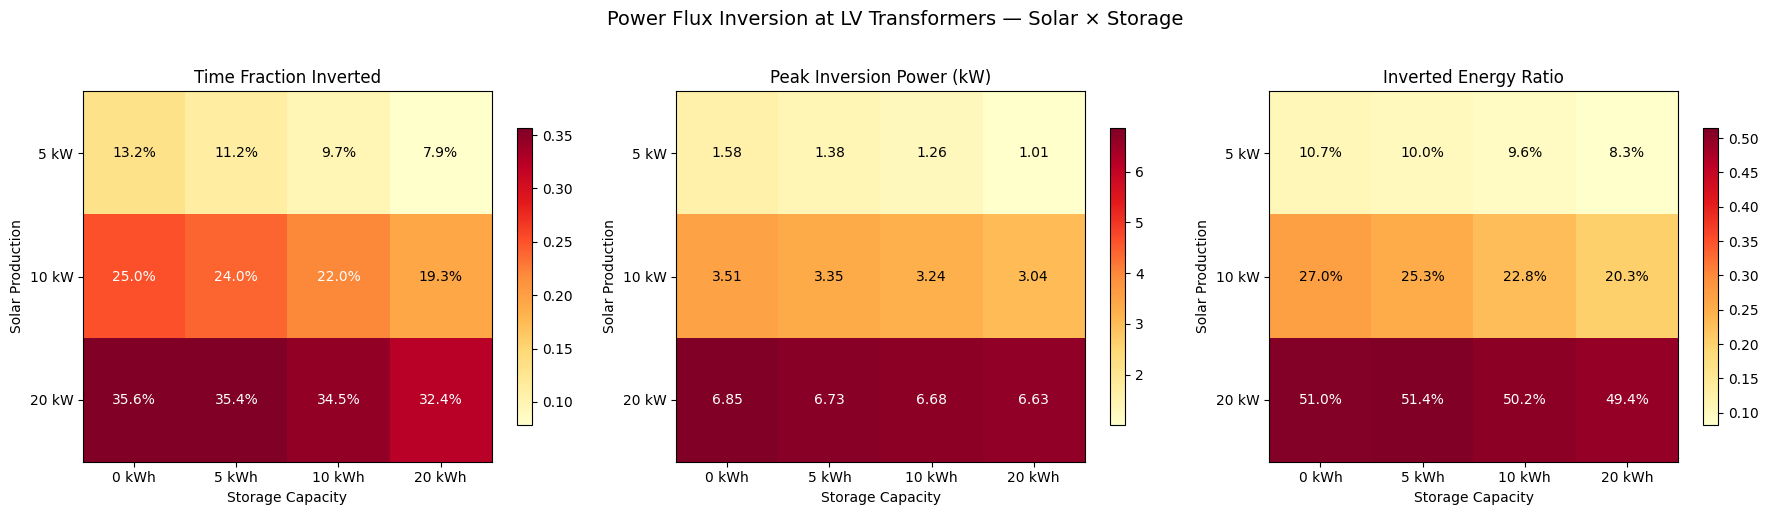

In [5]:
solar_levels = sorted(inv_df['solar_kw'].unique())
storage_levels = sorted(inv_df['storage_kwh'].unique())
colors_storage = {0: '#d62728', 5: '#ff7f0e', 10: '#2ca02c', 20: '#1f77b4'}
colors_solar = {5: '#2ca02c', 10: '#ff7f0e', 20: '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('inversion_time_fraction', 'Time Fraction Inverted', '{:.1%}'),
    ('peak_inversion_kw', 'Peak Inversion Power (kW)', '{:.2f}'),
    ('inversion_energy_ratio', 'Inverted Energy Ratio', '{:.1%}'),
]

for ax, (col, title, fmt) in zip(axes, metrics):
    pivot = inv_df.groupby(['solar_kw', 'storage_kwh'])[col].mean().unstack()
    pivot = pivot.reindex(index=solar_levels, columns=storage_levels)
    
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    
    ax.set_xticks(range(len(storage_levels)))
    ax.set_xticklabels([f'{s} kWh' for s in storage_levels])
    ax.set_yticks(range(len(solar_levels)))
    ax.set_yticklabels([f'{s} kW' for s in solar_levels])
    ax.set_xlabel('Storage Capacity')
    ax.set_ylabel('Solar Production')
    ax.set_title(title)
    
    for i in range(len(solar_levels)):
        for j in range(len(storage_levels)):
            val = pivot.values[i, j]
            text = fmt.format(val)
            ax.text(j, i, text, ha='center', va='center', fontsize=10,
                    color='white' if val > pivot.values.max() * 0.6 else 'black')
    
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Power Flux Inversion at LV Transformers — Solar × Storage', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Effect of Storage on Inversion (Box Plots per Solar Level)

For each solar level, shows how storage capacity reduces inversion across all transformer-phase pairs and 16 random seeds.

/tmp/ipykernel_500719/1397553429.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_storage, labels=[f'{s}' for s in storage_levels],
/tmp/ipykernel_500719/1397553429.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_storage, labels=[f'{s}' for s in storage_levels],
/tmp/ipykernel_500719/1397553429.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_storage, labels=[f'{s}' for s in storage_levels],


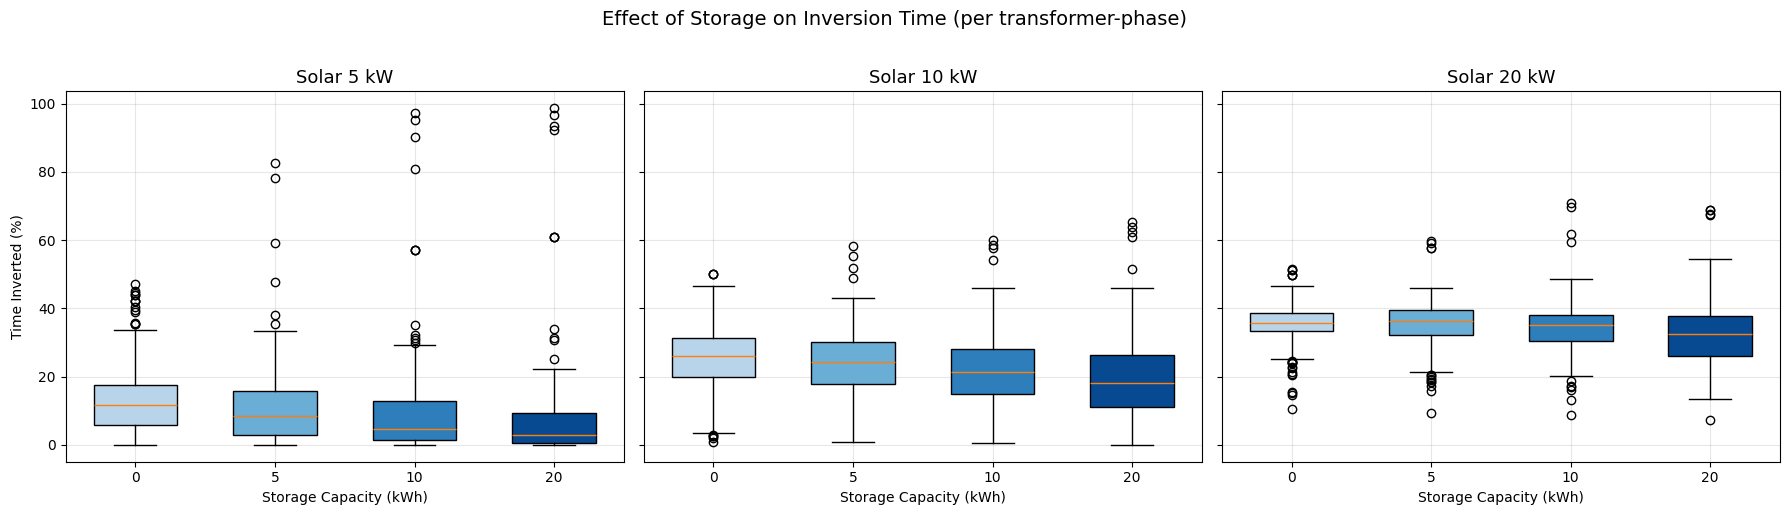

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, solar in zip(axes, solar_levels):
    subset = inv_df[inv_df['solar_kw'] == solar]
    
    data_by_storage = [subset[subset['storage_kwh'] == s]['inversion_time_fraction'].values * 100
                       for s in storage_levels]
    
    bp = ax.boxplot(data_by_storage, labels=[f'{s}' for s in storage_levels],
                    patch_artist=True, widths=0.6)
    
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(storage_levels)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'Solar {solar} kW', fontsize=13)
    ax.set_xlabel('Storage Capacity (kWh)')
    if ax == axes[0]:
        ax.set_ylabel('Time Inverted (%)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Storage on Inversion Time (per transformer-phase)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. PDF and CDF of Transformer Power — by Solar Level

Probability distribution of individual transformer-phase power for each solar level,
comparing storage capacities. The vertical red line marks P = 0 (inversion threshold).

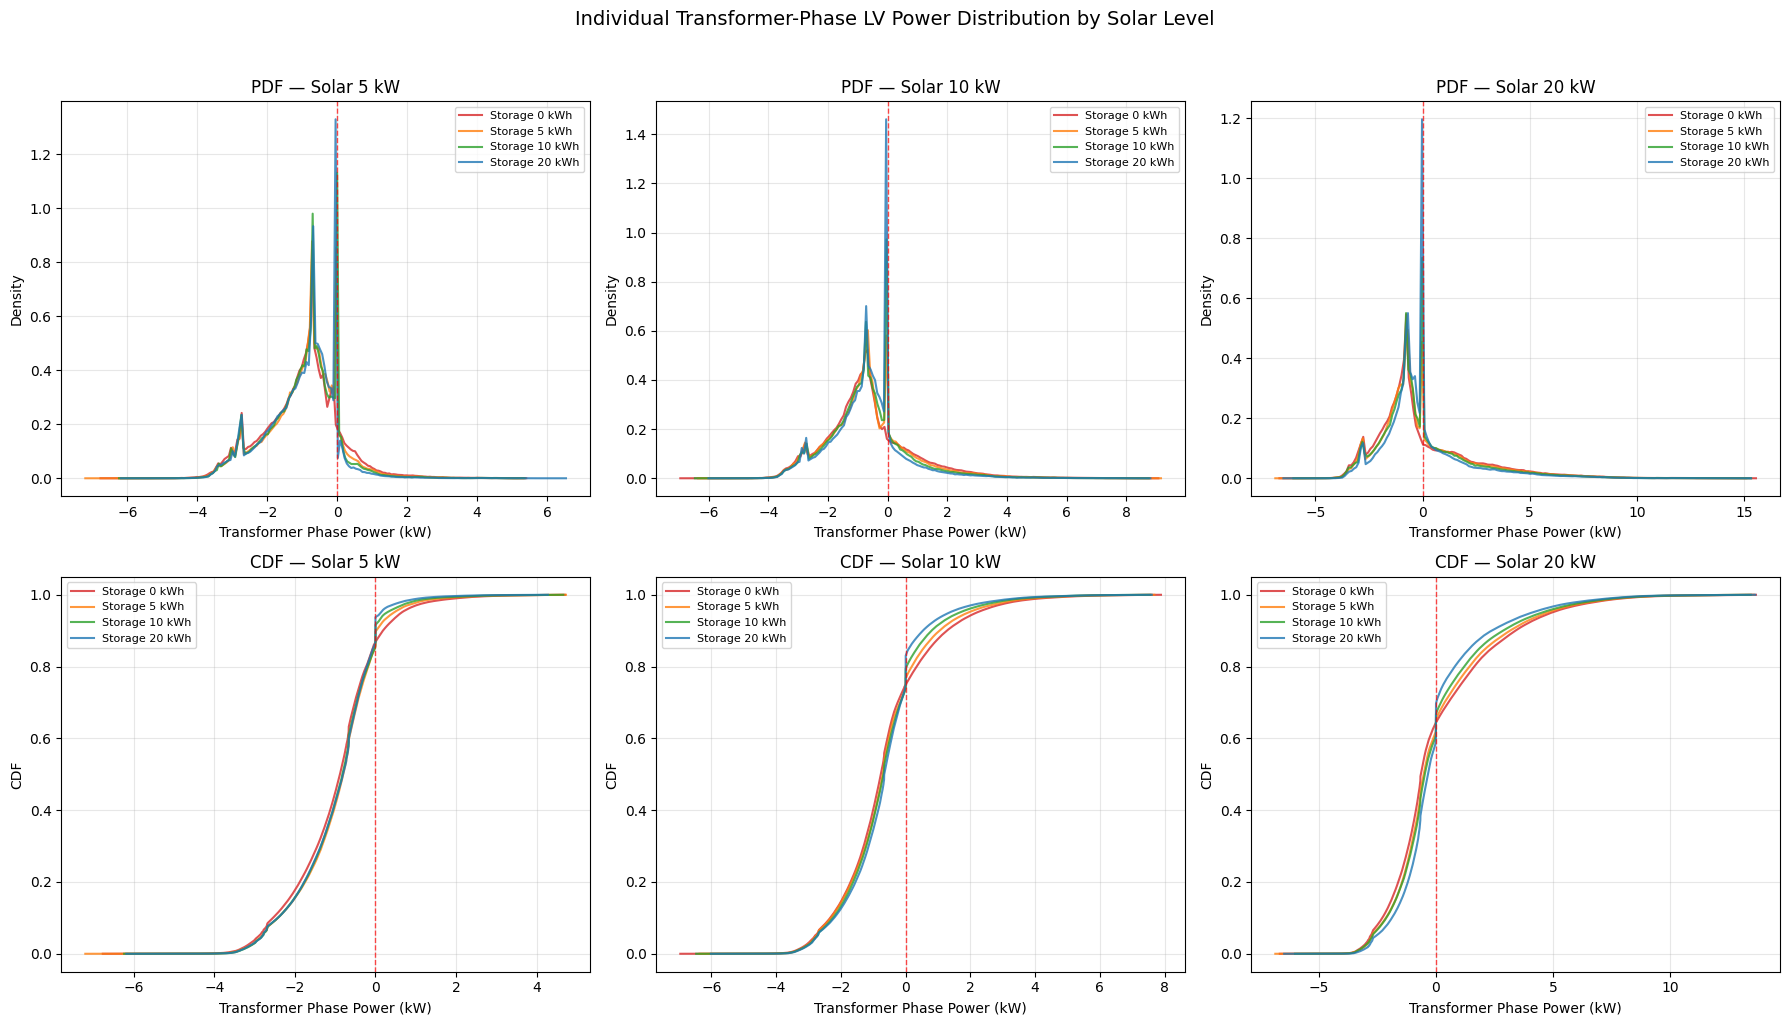

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, solar in enumerate(solar_levels):
    ax_pdf = axes[0, col_idx]
    ax_cdf = axes[1, col_idx]
    
    for storage in storage_levels:
        all_p = []
        for r in results:
            if r['solar_kw'] == solar and r['storage_kwh'] == storage:
                all_p.append(r['p_timeseries_kw'])
        
        if not all_p:
            continue
        
        combined = np.concatenate(all_p)
        label = f'Storage {storage} kWh'
        color = colors_storage[storage]
        
        hist, edges = np.histogram(combined, bins=200, density=True)
        ax_pdf.plot(edges[:-1], hist, label=label, color=color, alpha=0.8)
        
        sorted_data = np.sort(combined)
        cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        step = max(1, len(sorted_data) // 2000)
        ax_cdf.plot(sorted_data[::step], cdf[::step], label=label, color=color, alpha=0.8)
    
    ax_pdf.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax_pdf.set_title(f'PDF — Solar {solar} kW')
    ax_pdf.set_xlabel('Transformer Phase Power (kW)')
    ax_pdf.set_ylabel('Density')
    ax_pdf.legend(fontsize=8)
    ax_pdf.grid(True, alpha=0.3)
    
    ax_cdf.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax_cdf.set_title(f'CDF — Solar {solar} kW')
    ax_cdf.set_xlabel('Transformer Phase Power (kW)')
    ax_cdf.set_ylabel('CDF')
    ax_cdf.legend(fontsize=8)
    ax_cdf.grid(True, alpha=0.3)

plt.suptitle('Individual Transformer-Phase LV Power Distribution by Solar Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. PDF and CDF of Transformer Power — by Storage Level

Same distributions but grouped by storage level, comparing solar production effects.

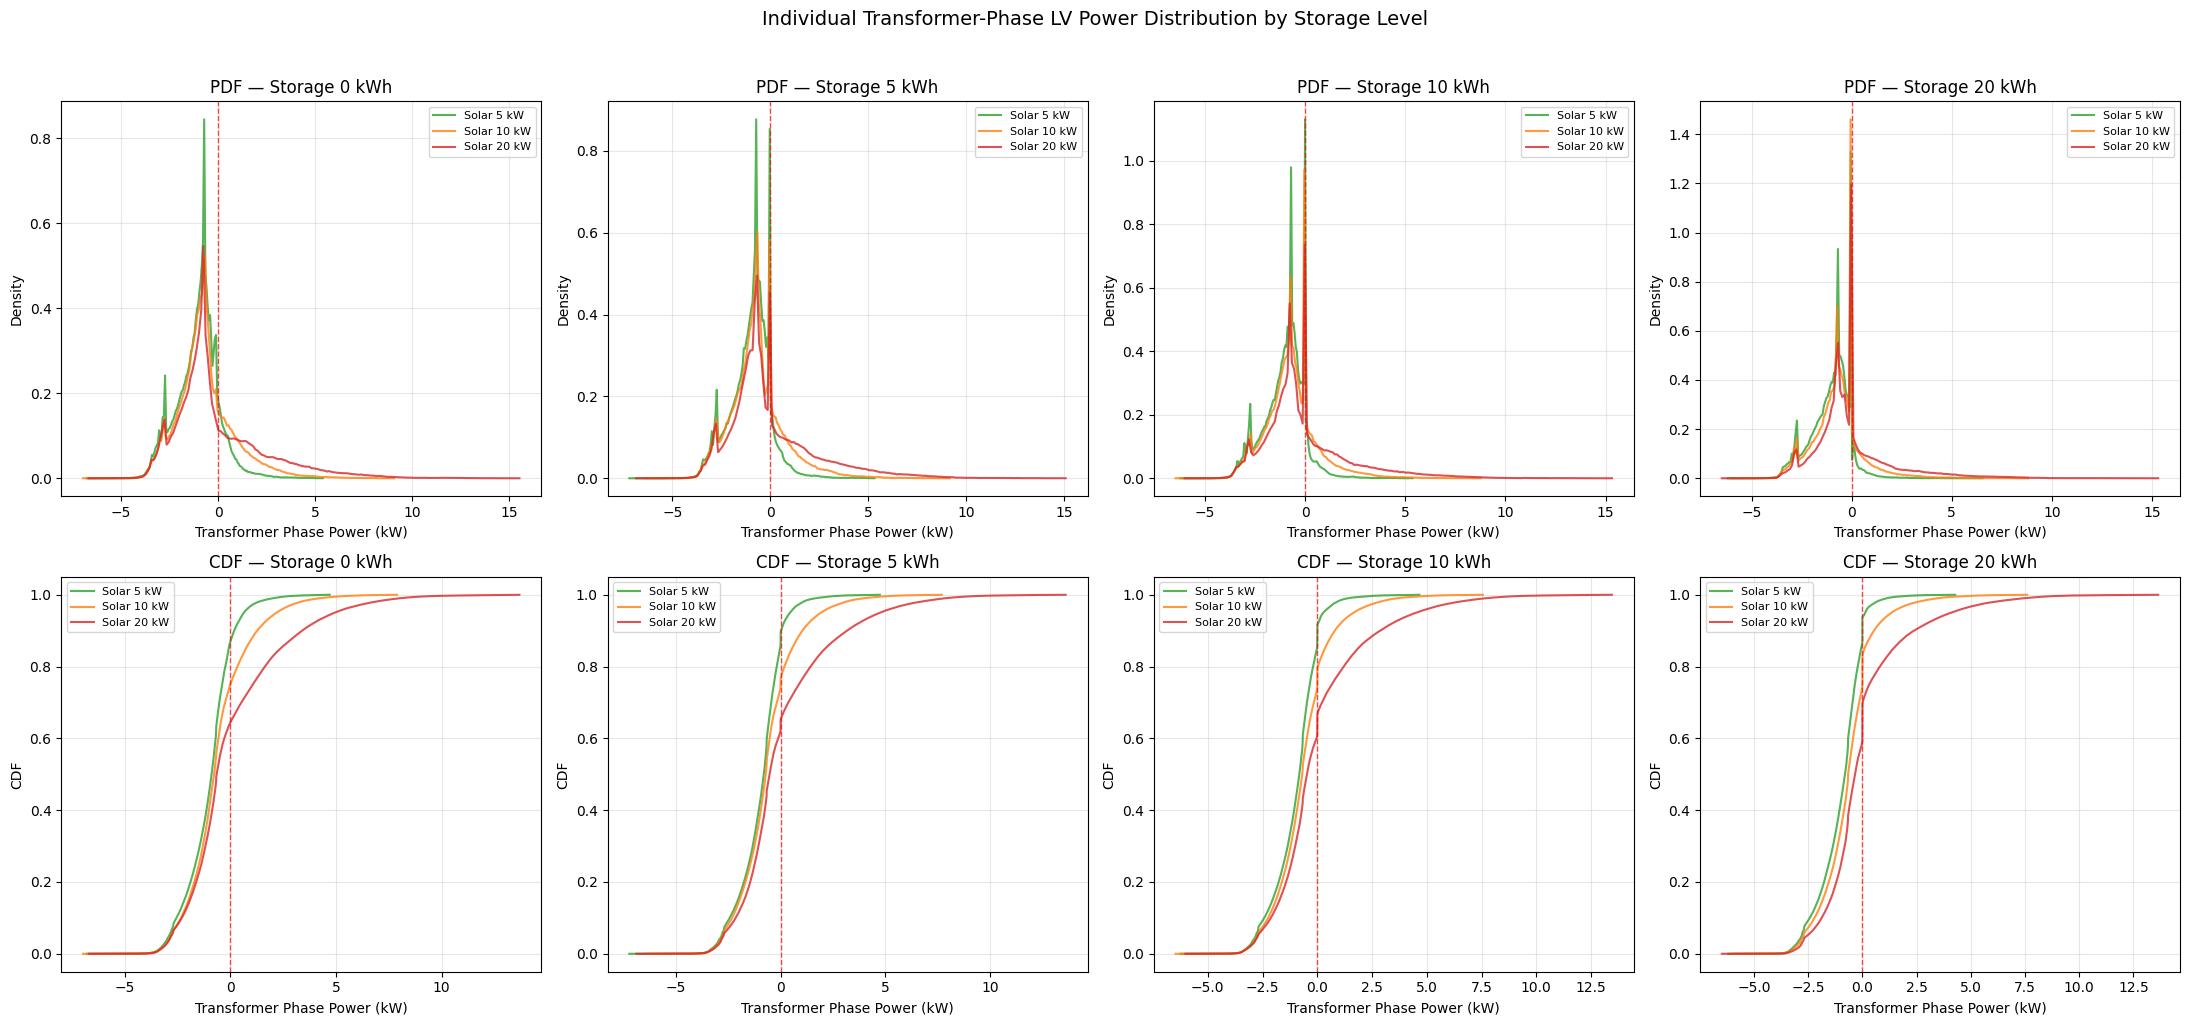

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for col_idx, storage in enumerate(storage_levels):
    ax_pdf = axes[0, col_idx]
    ax_cdf = axes[1, col_idx]
    
    for solar in solar_levels:
        all_p = []
        for r in results:
            if r['solar_kw'] == solar and r['storage_kwh'] == storage:
                all_p.append(r['p_timeseries_kw'])
        
        if not all_p:
            continue
        
        combined = np.concatenate(all_p)
        label = f'Solar {solar} kW'
        color = colors_solar[solar]
        
        hist, edges = np.histogram(combined, bins=200, density=True)
        ax_pdf.plot(edges[:-1], hist, label=label, color=color, alpha=0.8)
        
        sorted_data = np.sort(combined)
        cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        step = max(1, len(sorted_data) // 2000)
        ax_cdf.plot(sorted_data[::step], cdf[::step], label=label, color=color, alpha=0.8)
    
    ax_pdf.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax_pdf.set_title(f'PDF — Storage {storage} kWh')
    ax_pdf.set_xlabel('Transformer Phase Power (kW)')
    ax_pdf.set_ylabel('Density')
    ax_pdf.legend(fontsize=8)
    ax_pdf.grid(True, alpha=0.3)
    
    ax_cdf.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax_cdf.set_title(f'CDF — Storage {storage} kWh')
    ax_cdf.set_xlabel('Transformer Phase Power (kW)')
    ax_cdf.set_ylabel('CDF')
    ax_cdf.legend(fontsize=8)
    ax_cdf.grid(True, alpha=0.3)

plt.suptitle('Individual Transformer-Phase LV Power Distribution by Storage Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. CDF Zoom on Inversion Region (P > 0)

Zooms into the positive power region (inversion) to show how storage shifts the tail.
Y-axis = fraction of time spent above each power level.

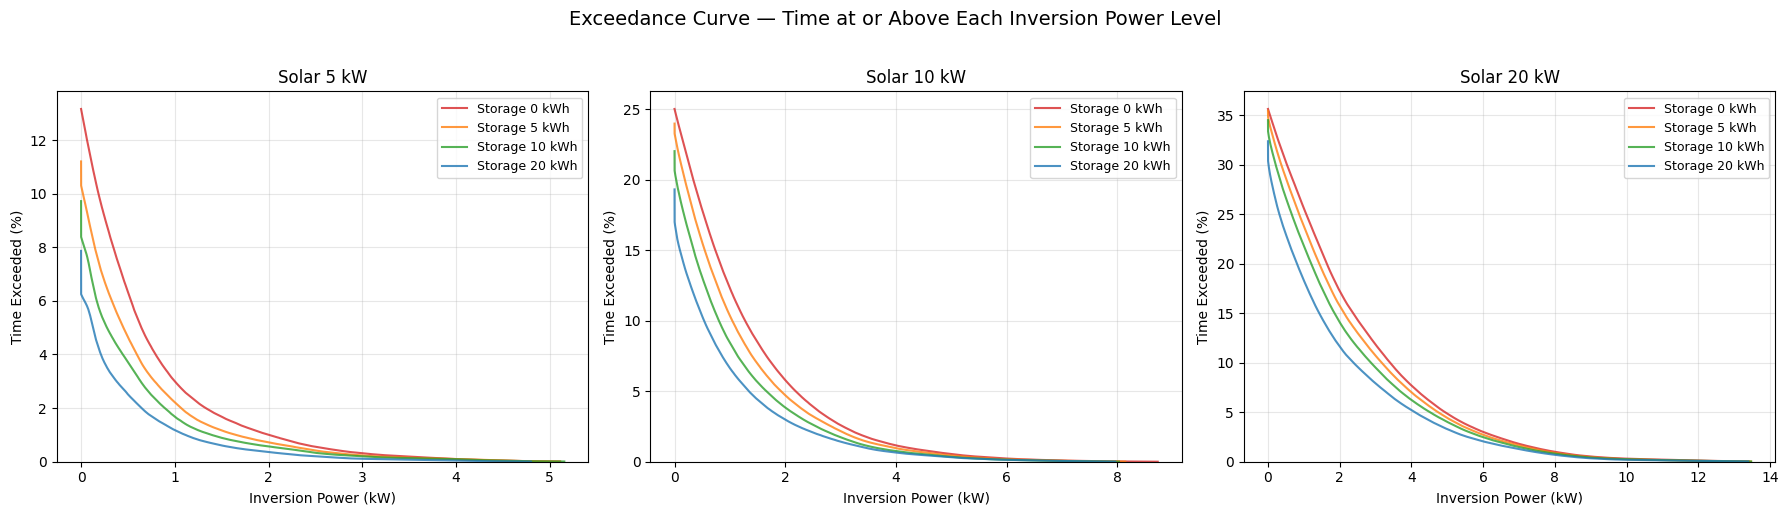

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, solar in zip(axes, solar_levels):
    for storage in storage_levels:
        all_p = []
        for r in results:
            if r['solar_kw'] == solar and r['storage_kwh'] == storage:
                all_p.append(r['p_timeseries_kw'])
        
        if not all_p:
            continue
        
        combined = np.concatenate(all_p)
        positive = combined[combined > 0]
        
        if len(positive) == 0:
            ax.axhline(0, color=colors_storage[storage], linestyle='--',
                       label=f'Storage {storage} kWh (no inversion)', alpha=0.5)
            continue
        
        sorted_pos = np.sort(positive)
        exceedance = np.arange(len(sorted_pos), 0, -1) / len(combined)
        
        step = max(1, len(sorted_pos) // 1000)
        ax.plot(sorted_pos[::step], exceedance[::step] * 100,
                label=f'Storage {storage} kWh', color=colors_storage[storage], alpha=0.8)
    
    ax.set_title(f'Solar {solar} kW')
    ax.set_xlabel('Inversion Power (kW)')
    ax.set_ylabel('Time Exceeded (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Exceedance Curve — Time at or Above Each Inversion Power Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Inversion Metrics vs Storage Capacity (Line Plots with Error Bands)

Shows how each inversion metric evolves as storage increases, with error bands showing
the spread across transformer-phase pairs and 16 random seeds.

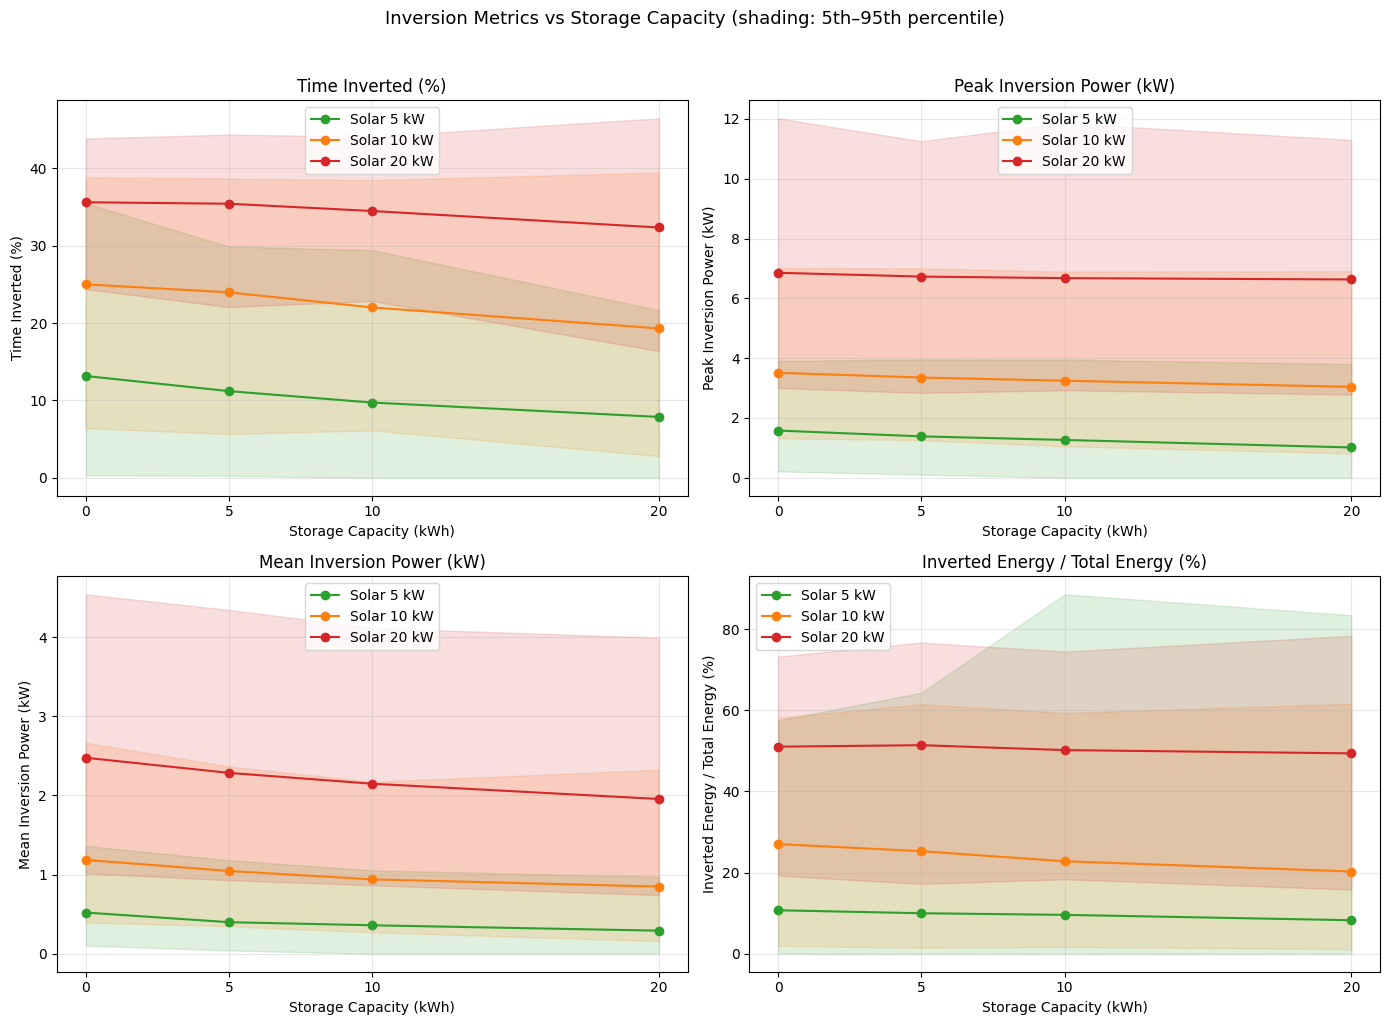

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metric_configs = [
    ('inversion_time_fraction', 'Time Inverted (%)', 100),
    ('peak_inversion_kw', 'Peak Inversion Power (kW)', 1),
    ('mean_inversion_kw', 'Mean Inversion Power (kW)', 1),
    ('inversion_energy_ratio', 'Inverted Energy / Total Energy (%)', 100),
]

for ax, (col, ylabel, scale) in zip(axes.flat, metric_configs):
    for solar in solar_levels:
        subset = inv_df[inv_df['solar_kw'] == solar]
        grouped = subset.groupby('storage_kwh')[col]
        
        means = grouped.mean() * scale
        p05 = grouped.quantile(0.05) * scale
        p95 = grouped.quantile(0.95) * scale
        
        color = colors_solar[solar]
        ax.plot(means.index, means.values, 'o-', label=f'Solar {solar} kW',
                color=color, markersize=6)
        ax.fill_between(means.index, p05.values, p95.values, alpha=0.15, color=color)
    
    ax.set_xlabel('Storage Capacity (kWh)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(storage_levels)

plt.suptitle('Inversion Metrics vs Storage Capacity (shading: 5th–95th percentile)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Inversion Metrics vs Solar Production (Line Plots with Error Bands)

Same metrics but with solar production on x-axis, one line per storage level.

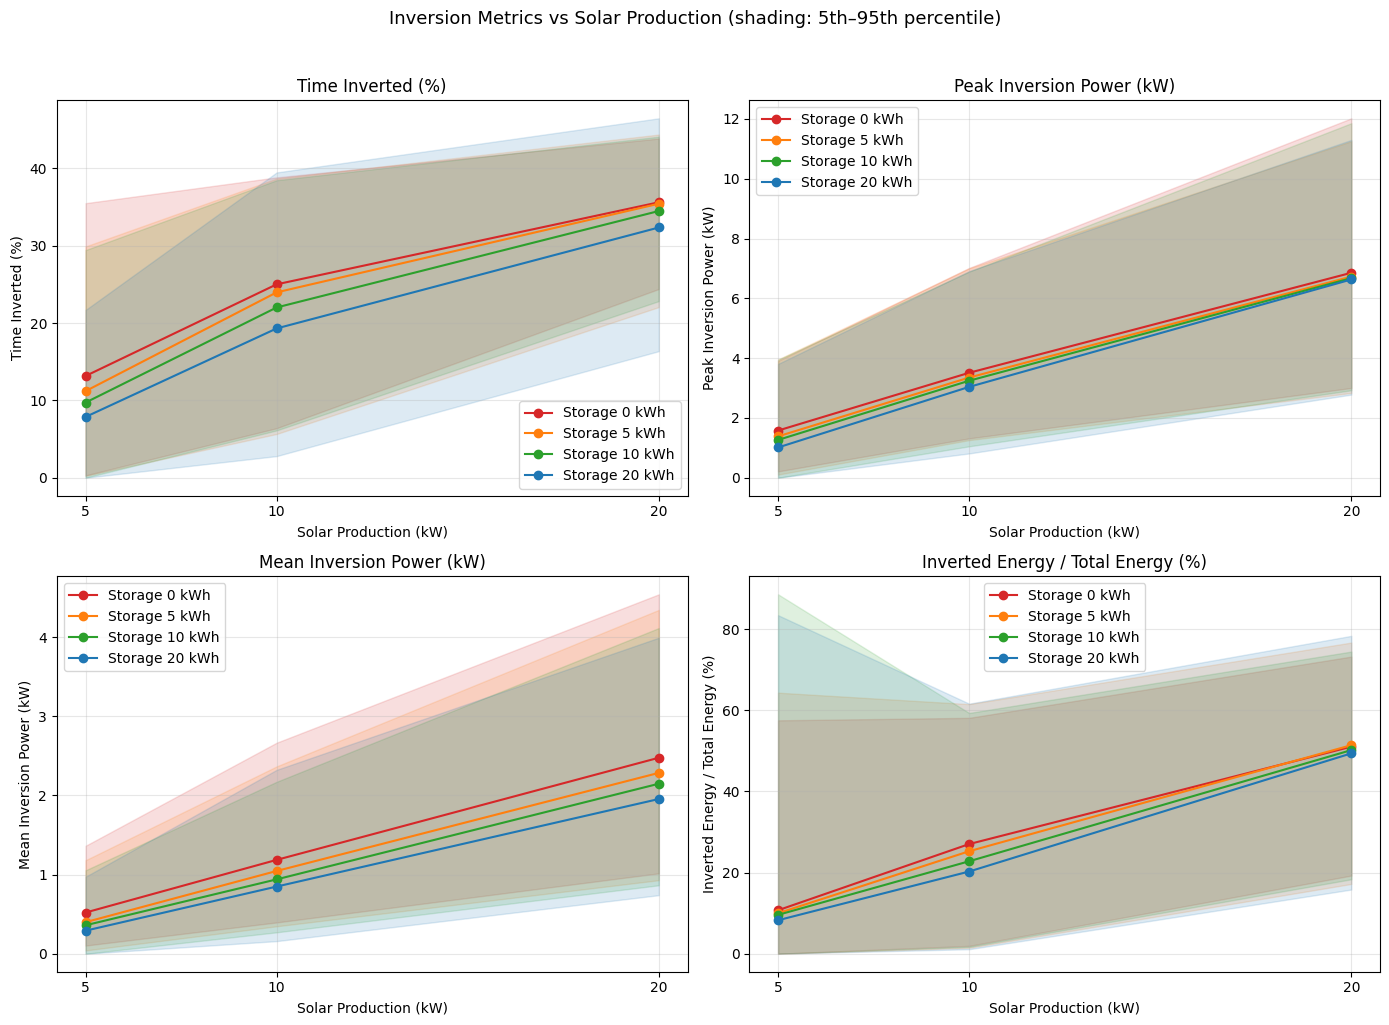

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, ylabel, scale) in zip(axes.flat, metric_configs):
    for storage in storage_levels:
        subset = inv_df[inv_df['storage_kwh'] == storage]
        grouped = subset.groupby('solar_kw')[col]
        
        means = grouped.mean() * scale
        p05 = grouped.quantile(0.05) * scale
        p95 = grouped.quantile(0.95) * scale
        
        color = colors_storage[storage]
        ax.plot(means.index, means.values, 'o-', label=f'Storage {storage} kWh',
                color=color, markersize=6)
        ax.fill_between(means.index, p05.values, p95.values, alpha=0.15, color=color)
    
    ax.set_xlabel('Solar Production (kW)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(solar_levels)

plt.suptitle('Inversion Metrics vs Solar Production (shading: 5th–95th percentile)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Per-Seed Scatter: Inversion Time vs Peak Inversion Power

Each dot is one (transformer, phase) from one simulation seed. Color = solar level, size = storage capacity.

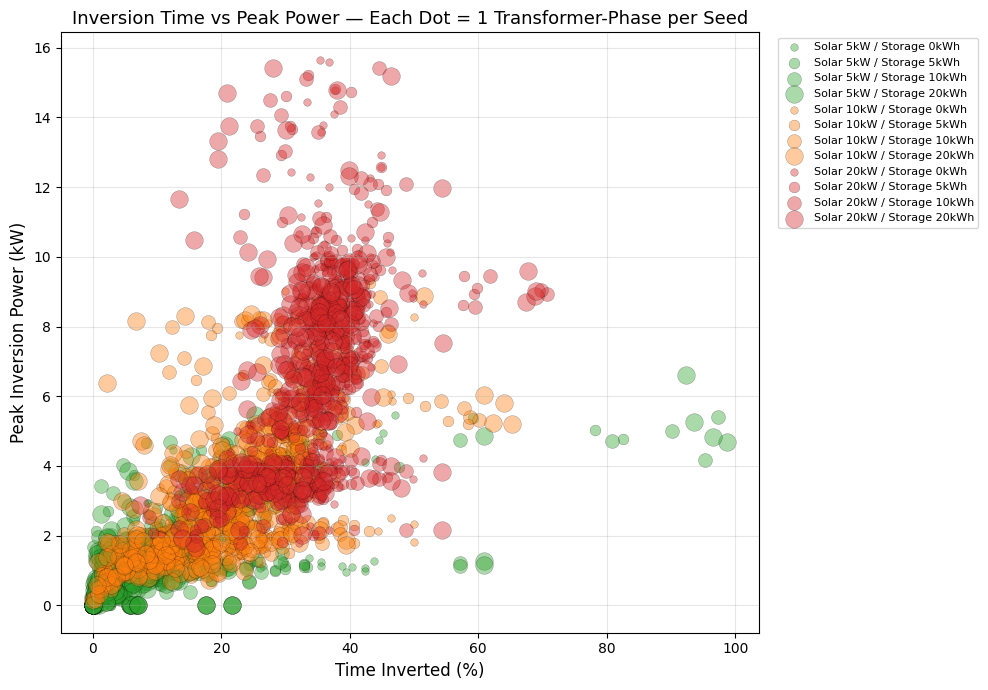

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

size_map = {0: 30, 5: 60, 10: 100, 20: 160}

for solar in solar_levels:
    for storage in storage_levels:
        mask = (inv_df['solar_kw'] == solar) & (inv_df['storage_kwh'] == storage)
        subset = inv_df[mask]
        ax.scatter(
            subset['inversion_time_fraction'] * 100,
            subset['peak_inversion_kw'],
            c=colors_solar[solar],
            s=size_map[storage],
            alpha=0.4,
            edgecolors='black',
            linewidths=0.3,
            label=f'Solar {solar}kW / Storage {storage}kWh'
        )

ax.set_xlabel('Time Inverted (%)', fontsize=12)
ax.set_ylabel('Peak Inversion Power (kW)', fontsize=12)
ax.set_title('Inversion Time vs Peak Power — Each Dot = 1 Transformer-Phase per Seed', fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Storage Effectiveness: Inversion Reduction Relative to No-Storage Baseline

For each solar level, shows how much storage reduces inversion compared to the no-storage (0 kWh) scenario.
100% means complete elimination of inversion.

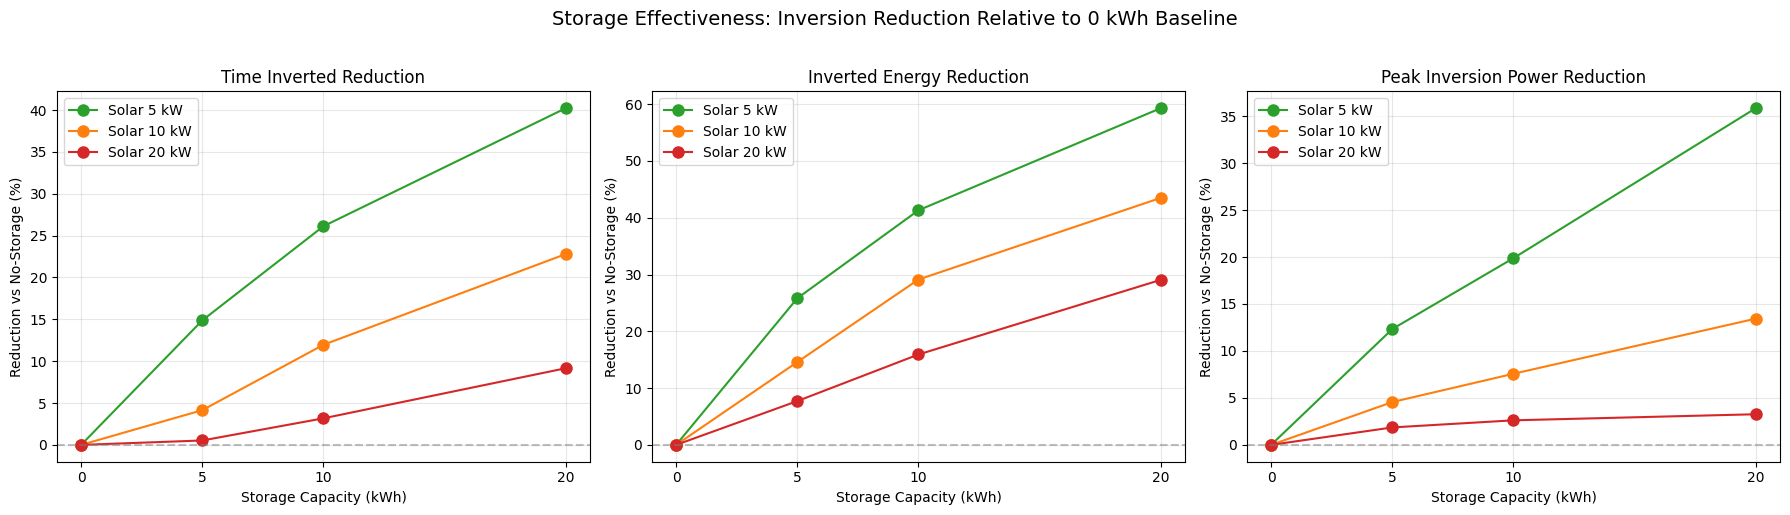

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

reduction_metrics = [
    ('inversion_time_fraction', 'Time Inverted'),
    ('total_inverted_kwh', 'Inverted Energy'),
    ('peak_inversion_kw', 'Peak Inversion Power'),
]

for ax, (col, title) in zip(axes, reduction_metrics):
    for solar in solar_levels:
        subset = inv_df[inv_df['solar_kw'] == solar]
        baseline = subset[subset['storage_kwh'] == 0][col].mean()
        
        if baseline <= 0:
            continue
        
        reductions = []
        for storage in storage_levels:
            current = subset[subset['storage_kwh'] == storage][col].mean()
            reduction_pct = (1 - current / baseline) * 100
            reductions.append(reduction_pct)
        
        ax.plot(storage_levels, reductions, 'o-', label=f'Solar {solar} kW',
                color=colors_solar[solar], markersize=8)
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Storage Capacity (kWh)')
    ax.set_ylabel('Reduction vs No-Storage (%)')
    ax.set_title(f'{title} Reduction')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(storage_levels)

plt.suptitle('Storage Effectiveness: Inversion Reduction Relative to 0 kWh Baseline', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 13. Daily Inversion Profile with Household Consumption

Shows the average daily pattern of individual transformer-phase power for each Solar×Storage combination.
Positive values (shaded red) indicate inversion periods.
**Green dashed line** shows the total household consumption profile — when solar generation exceeds this consumption, the surplus flows back through the transformer causing inversion.

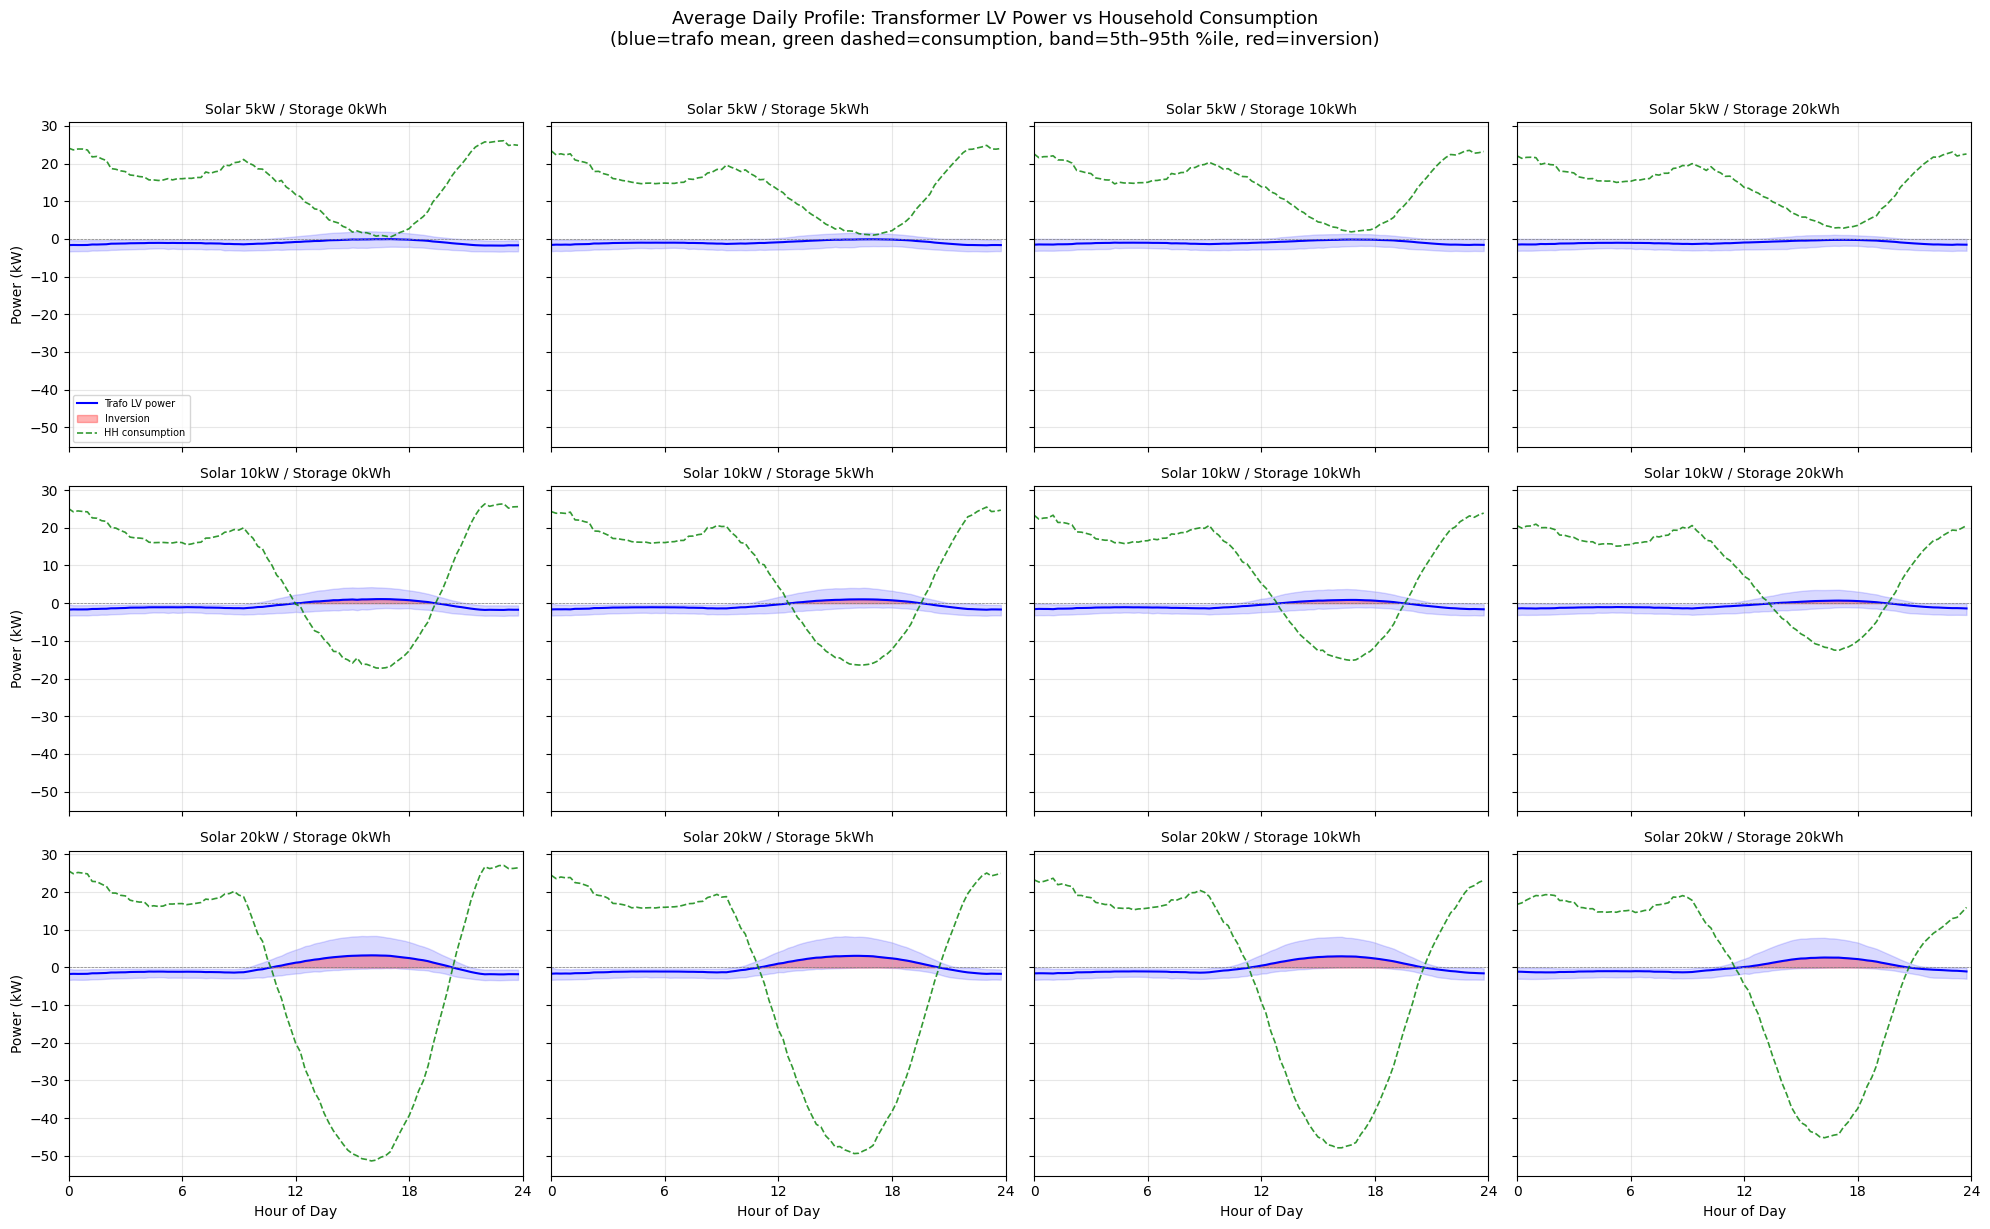

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)

for row_idx, solar in enumerate(solar_levels):
    for col_idx, storage in enumerate(storage_levels):
        ax = axes[row_idx, col_idx]
        
        # Transformer power daily profile
        all_daily = []
        for r in results:
            if r['solar_kw'] == solar and r['storage_kwh'] == storage:
                p = r['p_timeseries_kw']
                n_steps_per_day = 96
                n_days = len(p) // n_steps_per_day
                if n_days > 0:
                    trimmed = p[:n_days * n_steps_per_day]
                    daily = trimmed.reshape(n_days, n_steps_per_day)
                    all_daily.append(daily)
        
        # Household consumption daily profile
        all_daily_hh = []
        for r in household_results:
            if r['solar_kw'] == solar and r['storage_kwh'] == storage:
                c = r['consumption_timeseries_kw']
                n_steps_per_day = 96
                n_days = len(c) // n_steps_per_day
                if n_days > 0:
                    trimmed_c = c[:n_days * n_steps_per_day]
                    daily_c = trimmed_c.reshape(n_days, n_steps_per_day)
                    all_daily_hh.append(daily_c)
        
        if not all_daily:
            ax.set_visible(False)
            continue
        
        stacked = np.vstack(all_daily)
        mean_daily = np.mean(stacked, axis=0)
        p05_daily = np.percentile(stacked, 5, axis=0)
        p95_daily = np.percentile(stacked, 95, axis=0)
        
        hours = np.arange(96) * 0.25
        
        ax.plot(hours, mean_daily, 'b-', linewidth=1.5, label='Trafo LV power')
        ax.fill_between(hours, p05_daily, p95_daily, alpha=0.15, color='blue')
        ax.fill_between(hours, 0, mean_daily, where=mean_daily > 0,
                        alpha=0.3, color='red', label='Inversion')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        
        # Overlay household consumption
        if all_daily_hh:
            stacked_hh = np.vstack(all_daily_hh)
            mean_daily_hh = np.mean(stacked_hh, axis=0)
            ax.plot(hours, mean_daily_hh, color='green', linewidth=1.2,
                    linestyle='--', alpha=0.8, label='HH consumption')
        
        ax.set_title(f'Solar {solar}kW / Storage {storage}kWh', fontsize=10)
        if row_idx == 2:
            ax.set_xlabel('Hour of Day')
        if col_idx == 0:
            ax.set_ylabel('Power (kW)')
        ax.set_xlim(0, 24)
        ax.set_xticks([0, 6, 12, 18, 24])
        ax.grid(True, alpha=0.3)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc='lower left')

plt.suptitle('Average Daily Profile: Transformer LV Power vs Household Consumption\n'
             '(blue=trafo mean, green dashed=consumption, band=5th–95th %ile, red=inversion)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13b. Household Consumption vs Inversion Balance

Shows the net power balance: how household consumption offsets solar generation.
Compares total energy consumed vs total energy inverted for each Solar×Storage combination.

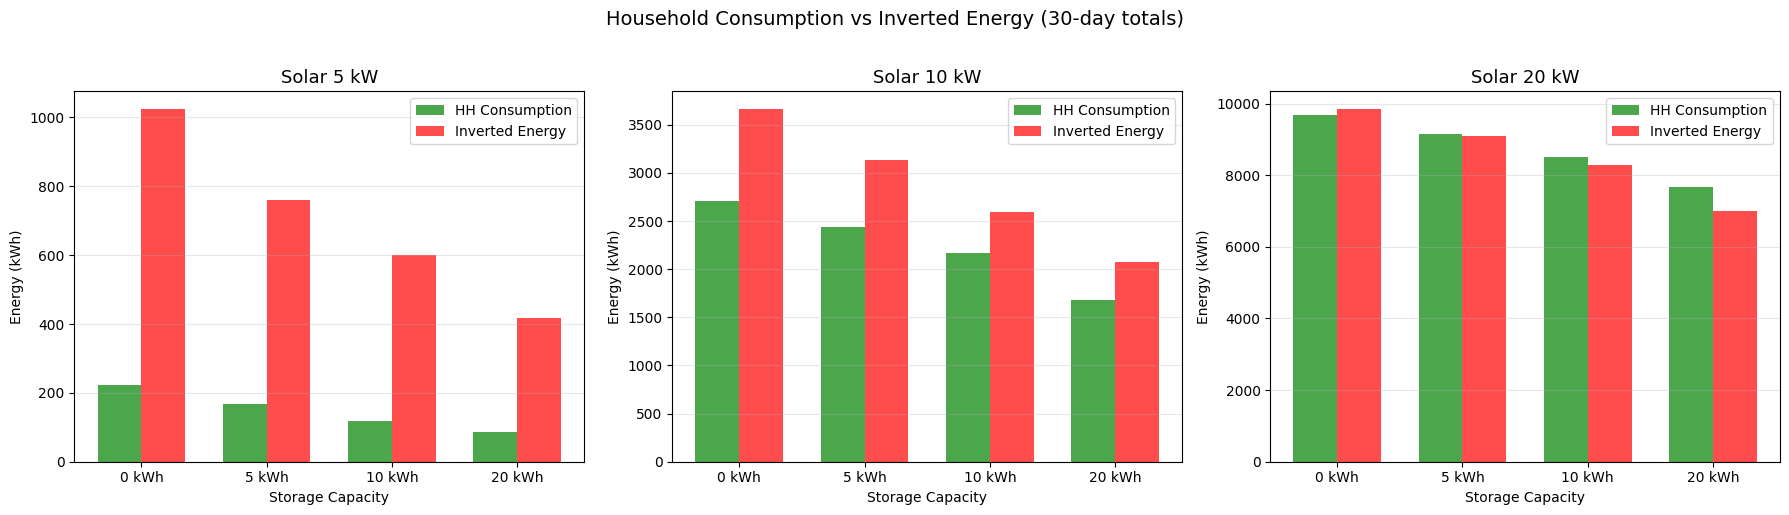

In [19]:
# Consumption vs Inversion energy balance per Solar×Storage combo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, solar in zip(axes, solar_levels):
    consumed = []
    inverted_e = []
    labels = []
    
    for storage in storage_levels:
        subset = inv_df[(inv_df['solar_kw'] == solar) & (inv_df['storage_kwh'] == storage)]
        # Total consumed is per simulation (same for all trafo-phase records of that sim)
        sim_consumed = subset.groupby('simulation_output_id')['total_consumed_kwh'].first().mean()
        # Total inverted is per trafo-phase, sum across all trafo-phases per sim then average
        sim_inverted = subset.groupby('simulation_output_id')['total_inverted_kwh'].sum().mean()
        
        consumed.append(sim_consumed)
        inverted_e.append(sim_inverted)
        labels.append(f'{storage} kWh')
    
    x = np.arange(len(storage_levels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, consumed, width, label='HH Consumption', color='green', alpha=0.7)
    bars2 = ax.bar(x + width/2, inverted_e, width, label='Inverted Energy', color='red', alpha=0.7)
    
    ax.set_title(f'Solar {solar} kW', fontsize=13)
    ax.set_xlabel('Storage Capacity')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Energy (kWh)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Household Consumption vs Inverted Energy (30-day totals)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Summary: Key Findings

Compact view of the storage impact numbers.

In [20]:
print('=' * 100)
print('STORAGE IMPACT ON POWER FLUX INVERSION — KEY NUMBERS')
print('(metrics computed per individual transformer-phase, not summed)')
print('=' * 100)

for solar in solar_levels:
    subset = inv_df[inv_df['solar_kw'] == solar]
    baseline_time = subset[subset['storage_kwh'] == 0]['inversion_time_fraction'].mean()
    baseline_energy = subset[subset['storage_kwh'] == 0]['total_inverted_kwh'].mean()
    baseline_peak = subset[subset['storage_kwh'] == 0]['peak_inversion_kw'].mean()
    
    # Household consumption (per simulation, not per trafo-phase)
    hh_sub = hh_consumption_df[hh_consumption_df['solar_kw'] == solar]
    mean_hh_consumption = hh_sub['mean_consumption_kw'].mean()
    total_hh_consumed = hh_sub['total_consumed_kwh'].mean()
    peak_hh_consumption = hh_sub['peak_consumption_kw'].mean()
    
    print(f'\nSolar {solar} kW (baseline without storage):')
    print(f'  Time inverted:        {baseline_time:.1%}')
    print(f'  Inverted energy:      {baseline_energy:.1f} kWh per trafo-phase over 30 days')
    print(f'  Peak inversion:       {baseline_peak:.2f} kW')
    print(f'  --- Household Consumption ---')
    print(f'  Mean consumption:     {mean_hh_consumption:.2f} kW (all households, all phases)')
    print(f'  Total consumed:       {total_hh_consumed:.1f} kWh over 30 days')
    print(f'  Peak consumption:     {peak_hh_consumption:.2f} kW')
    
    for storage in [5, 10, 20]:
        s = subset[subset['storage_kwh'] == storage]
        time_red = (1 - s['inversion_time_fraction'].mean() / baseline_time) * 100 if baseline_time > 0 else 0
        energy_red = (1 - s['total_inverted_kwh'].mean() / baseline_energy) * 100 if baseline_energy > 0 else 0
        peak_red = (1 - s['peak_inversion_kw'].mean() / baseline_peak) * 100 if baseline_peak > 0 else 0
        print(f'  + {storage} kWh storage → time: {time_red:+.1f}%  energy: {energy_red:+.1f}%  peak: {peak_red:+.1f}%')

print('\n' + '=' * 100)

STORAGE IMPACT ON POWER FLUX INVERSION — KEY NUMBERS
(metrics computed per individual transformer-phase, not summed)

Solar 5 kW (baseline without storage):
  Time inverted:        13.2%
  Inverted energy:      68.3 kWh per trafo-phase over 30 days
  Peak inversion:       1.58 kW
  --- Household Consumption ---
  Mean consumption:     2.81 kW (all households, all phases)
  Total consumed:       149.1 kWh over 30 days
  Peak consumption:     11.06 kW
  + 5 kWh storage → time: +14.9%  energy: +25.8%  peak: +12.3%
  + 10 kWh storage → time: +26.1%  energy: +41.3%  peak: +19.9%
  + 20 kWh storage → time: +40.2%  energy: +59.3%  peak: +35.8%

Solar 10 kW (baseline without storage):
  Time inverted:        25.0%
  Inverted energy:      244.3 kWh per trafo-phase over 30 days
  Peak inversion:       3.51 kW
  --- Household Consumption ---
  Mean consumption:     11.29 kW (all households, all phases)
  Total consumed:       2250.4 kWh over 30 days
  Peak consumption:     35.27 kW
  + 5 kWh stor